Feature Extraction & Viterbi Decoding
**Assignment:** Formative 2 — Hidden Markov Models  
**Role:**Data Loading, Feature Extraction, Viterbi Decoding, Visualizations   
**Sampling Rate:** 100 Hz (10ms intervals)  
**Activities collected by Person 1:** Jumping, Still  
**Activities collected by Person 2:** Walking, Standing

### Folder structure expected
```
data/raw/
  jumping/    ← Person 1's zip files
  still/      ← Person 1's zip files
  walking/    ← Person 2's zip files
  standing/   ← Person 2's zip files
```

Imports

In [42]:
import os
import zipfile
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('All imports successful!')

All imports successful!


Configuration

**Window size justification:**  
At 100 Hz, 100 samples = exactly 1 second. One full jump cycle (takeoff → air → land)
takes ~0.5–1.0 seconds, so a 1-second window reliably captures at least one complete
cycle without blending across activity boundaries. A 50-sample step (50% overlap)
doubles the number of training windows without introducing full duplication.

**Sampling rate harmonization:**  
Clollected dat with Sensor Logger configured at 10ms intervals
(100 Hz) for Accelerometer and Gyroscope.Verified via `Metadata.csv` inside
each zip file (`sampleRateMs=10`). No resampling was required.

In [43]:
# ── UPDATE THIS PATH to your local data folder ──────────────────────────────
DATA_DIR  = '../data/raw'       # folder containing jumping/, still/, walking/, standing/
FIG_DIR   = '../figures'
MODEL_DIR = '../models'
OUT_DIR   = '../data/processed'

for d in [FIG_DIR, MODEL_DIR, OUT_DIR]:
    os.makedirs(d, exist_ok=True)

ACTIVITIES  = ['jumping', 'still', 'walking', 'standing']
SAMPLE_RATE = 100          # Hz
WINDOW_SEC  = 1.0          # seconds
STEP_SEC    = 0.5          # seconds (50% overlap)
WINDOW_SIZE = int(WINDOW_SEC * SAMPLE_RATE)   # 100 samples
STEP_SIZE   = int(STEP_SEC   * SAMPLE_RATE)   # 50 samples

COLORS = {
    'jumping' : 'tomato',
    'still'   : 'darkorange',
    'walking' : 'seagreen',
    'standing': 'steelblue'
}

print(f'Data directory : {os.path.abspath(DATA_DIR)}')
print(f'Window size    : {WINDOW_SIZE} samples = {WINDOW_SEC}s')
print(f'Step size      : {STEP_SIZE} samples = {STEP_SEC}s (50% overlap)')
print(f'Sampling rate  : {SAMPLE_RATE} Hz')

Data directory : /home/umugabekazi/Desktop/HMM-Human-Activity-Recognition/data/raw
Window size    : 100 samples = 1.0s
Step size      : 50 samples = 0.5s (50% overlap)
Sampling rate  : 100 Hz


## Cell 3 — Data Loading Functions

In [29]:
def load_sensor_from_zip(zip_path, sensor='Accelerometer'):
    """
    Extract a sensor CSV from a Sensor Logger zip file.
    Automatically skips Uncalibrated variants.
    Returns DataFrame: seconds_elapsed, x, y, z
    """
    with zipfile.ZipFile(zip_path, 'r') as z:
        candidates = [
            f for f in z.namelist()
            if f.endswith(f'{sensor}.csv') and 'Uncalibrated' not in f
        ]
        if not candidates:
            raise FileNotFoundError(f'{sensor}.csv not found in {zip_path}')
        with z.open(candidates[0]) as f:
            df = pd.read_csv(f)
    df.columns = df.columns.str.strip()
    return df[['seconds_elapsed', 'x', 'y', 'z']].dropna().reset_index(drop=True)


def load_activity_from_zips(activity):
    """
    Load all zip files for one activity from data/<activity>/ folder.
    Merges Accelerometer + Gyroscope per zip on nearest timestamp.
    Returns combined DataFrame with columns:
      seconds_elapsed, acc_x, acc_y, acc_z,
      gyro_x, gyro_y, gyro_z, activity, recording_id
    """
    act_dir   = os.path.join(DATA_DIR, activity)
    zip_files = sorted([f for f in os.listdir(act_dir) if f.endswith('.zip')])

    if not zip_files:
        raise FileNotFoundError(f'No zip files found in {act_dir}')

    frames = []
    for rec_id, zf in enumerate(zip_files, start=1):
        zip_path = os.path.join(act_dir, zf)
        try:
            acc = load_sensor_from_zip(zip_path, 'Accelerometer')
            gyr = load_sensor_from_zip(zip_path, 'Gyroscope')
        except Exception as e:
            print(f'  WARNING: skipping {zf} — {e}')
            continue

        # Rename axes
        acc = acc.rename(columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'})
        gyr = gyr.rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})

        # Merge on nearest timestamp (tolerance = 20ms)
        merged = pd.merge_asof(
            acc.sort_values('seconds_elapsed'),
            gyr.sort_values('seconds_elapsed'),
            on='seconds_elapsed',
            direction='nearest',
            tolerance=0.02
        ).dropna().reset_index(drop=True)

        merged['activity']     = activity
        merged['recording_id'] = f'{activity}_{rec_id:02d}'
        frames.append(merged)

    if not frames:
        raise ValueError(f'No valid data loaded for activity: {activity}')

    return pd.concat(frames, ignore_index=True)


print('Data loading functions ready!')

Data loading functions ready!


## Cell 4 — Load All Activities

In [30]:
raw_data = {}

for act in ACTIVITIES:
    raw_data[act] = load_activity_from_zips(act)
    n_recs   = raw_data[act]['recording_id'].nunique()
    n_rows   = len(raw_data[act])
    duration = raw_data[act].groupby('recording_id')['seconds_elapsed'].max().sum()
    print(f'{act:>10} | {n_recs:>3} recordings | {n_rows:>6} rows | ~{duration:.0f}s total')

all_raw = pd.concat(raw_data.values(), ignore_index=True)
print(f'\n{"TOTAL":>10} | {all_raw["recording_id"].nunique():>3} recordings | {len(all_raw):>6} rows')

   jumping |  12 recordings |  13856 rows | ~141s total
     still |  14 recordings |  12623 rows | ~130s total
   walking |  13 recordings |  10436 rows | ~107s total
  standing |  10 recordings |  11299 rows | ~115s total

     TOTAL |  49 recordings |  48214 rows


## Cell 5 — Visualize Raw Sensor Signals

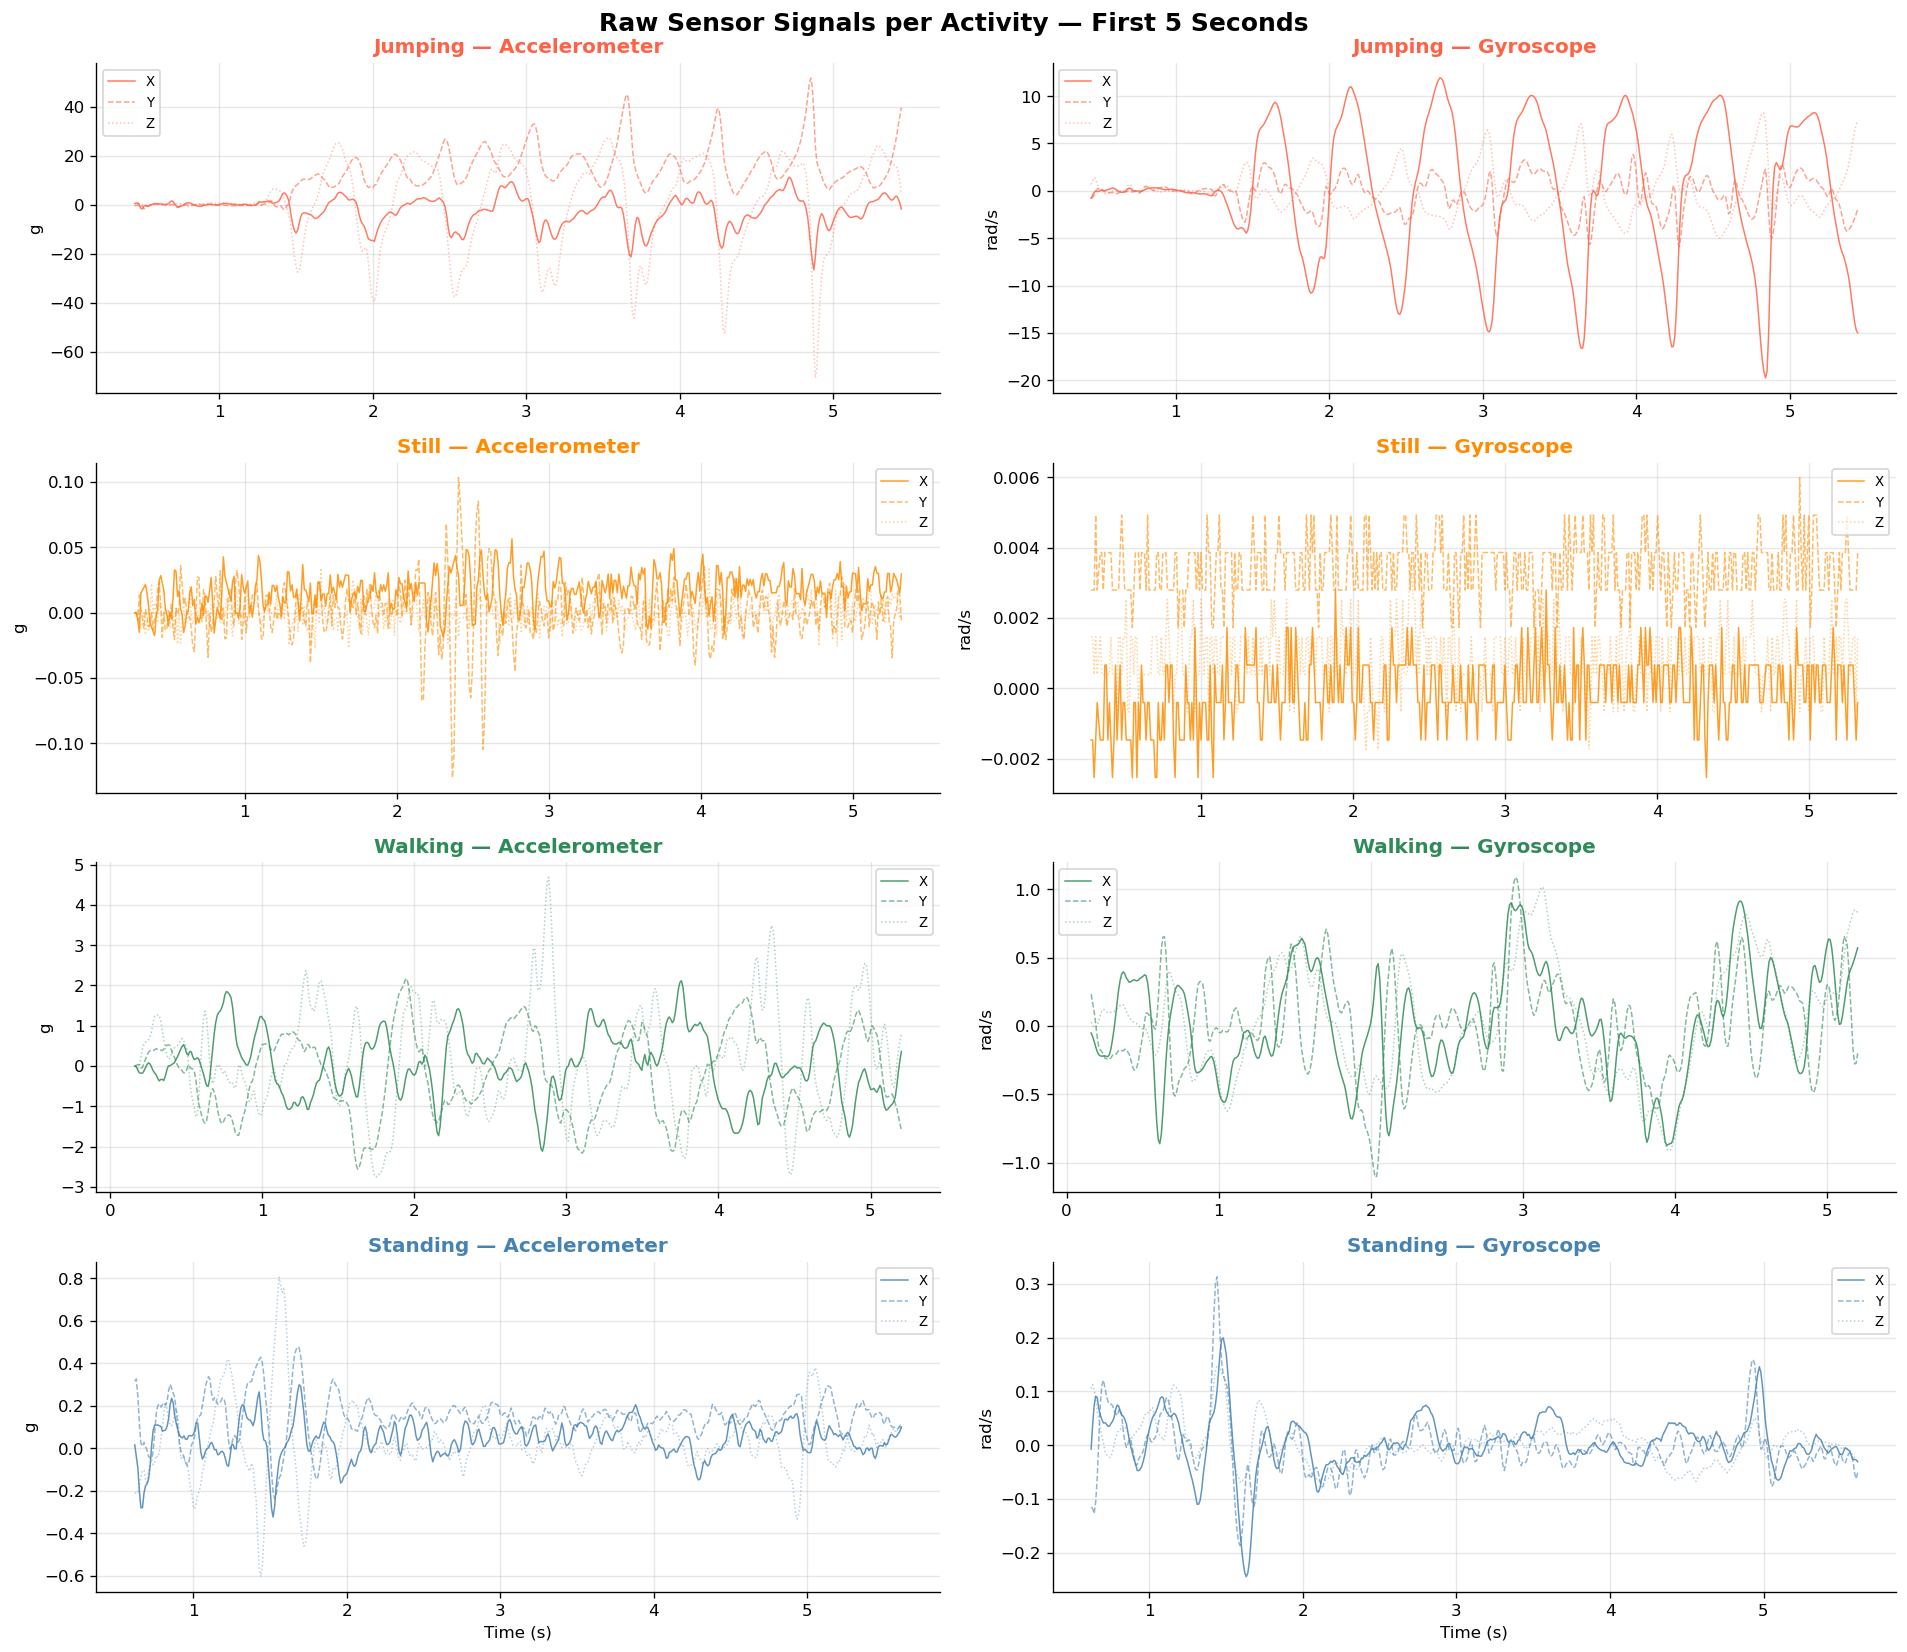

Saved: figures/raw_signals.png


In [31]:
# Plot first 5 seconds of each activity (accelerometer + gyroscope)
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Raw Sensor Signals per Activity — First 5 Seconds',
             fontsize=15, fontweight='bold')

for i, act in enumerate(ACTIVITIES):
    df = raw_data[act].iloc[:500]   # first 5 seconds at 100Hz
    t  = df['seconds_elapsed'].values
    c  = COLORS[act]

    # Accelerometer
    axes[i, 0].plot(t, df['acc_x'], alpha=0.85, linewidth=0.9, label='X', color=c)
    axes[i, 0].plot(t, df['acc_y'], alpha=0.60, linewidth=0.9, label='Y', color=c, linestyle='--')
    axes[i, 0].plot(t, df['acc_z'], alpha=0.40, linewidth=0.9, label='Z', color=c, linestyle=':')
    axes[i, 0].set_title(f'{act.capitalize()} — Accelerometer', fontweight='bold', color=c)
    axes[i, 0].set_ylabel('g')
    axes[i, 0].legend(fontsize=8)
    axes[i, 0].grid(alpha=0.3)

    # Gyroscope
    axes[i, 1].plot(t, df['gyro_x'], alpha=0.85, linewidth=0.9, label='X', color=c)
    axes[i, 1].plot(t, df['gyro_y'], alpha=0.60, linewidth=0.9, label='Y', color=c, linestyle='--')
    axes[i, 1].plot(t, df['gyro_z'], alpha=0.40, linewidth=0.9, label='Z', color=c, linestyle=':')
    axes[i, 1].set_title(f'{act.capitalize()} — Gyroscope', fontweight='bold', color=c)
    axes[i, 1].set_ylabel('rad/s')
    axes[i, 1].legend(fontsize=8)
    axes[i, 1].grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'raw_signals.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/raw_signals.png')

## Cell 6 — Feature Extraction

### Time-domain features (per axis)
| Feature | Why it helps distinguish activities |
|---|---|
| Mean | Captures average signal direction per activity |
| Variance | Near-zero for still/standing, high for jumping |
| Std deviation | Spread of motion; large for dynamic activities |
| RMS | Signal energy; jumping produces very high RMS |
| SMA | Total movement energy summed across all axes |
| Correlation xy, xz | Captures coordinated multi-axis motion patterns |

### Frequency-domain features (accelerometer axes, via FFT)
| Feature | Why it helps |
|---|---|
| Dominant frequency | Jumping ~1–3 Hz, walking ~2 Hz, still ~0 Hz |
| Spectral energy | Total power across spectrum; high for energetic activities |
| Spectral entropy | Low for periodic motion (jumping), high for irregular motion |

In [32]:
def extract_features(window):
    """
    Extract 26 time-domain and frequency-domain features from one window.
    Input : DataFrame with columns acc_x/y/z and gyro_x/y/z (WINDOW_SIZE rows)
    Output: dict of feature_name -> value
    """
    feats = {}
    sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

    # ── Time-domain features ────────────────────────────────────────────────
    for col in sensor_cols:
        sig = window[col].values
        feats[f'{col}_mean'] = np.mean(sig)
        feats[f'{col}_var']  = np.var(sig)
        feats[f'{col}_std']  = np.std(sig)
        feats[f'{col}_rms']  = np.sqrt(np.mean(sig ** 2))

    # Signal Magnitude Area — total energy across all acc axes
    feats['acc_sma'] = np.sum(
        np.abs(window['acc_x']) + np.abs(window['acc_y']) + np.abs(window['acc_z'])
    ) / len(window)

    # Signal Magnitude Area — total energy across all gyro axes
    feats['gyro_sma'] = np.sum(
        np.abs(window['gyro_x']) + np.abs(window['gyro_y']) + np.abs(window['gyro_z'])
    ) / len(window)

    # Correlation between accelerometer axes (captures coordination of movement)
    feats['acc_corr_xy'] = np.corrcoef(window['acc_x'], window['acc_y'])[0, 1]
    feats['acc_corr_xz'] = np.corrcoef(window['acc_x'], window['acc_z'])[0, 1]

    # ── Frequency-domain features (FFT) ─────────────────────────────────────
    for col in ['acc_x', 'acc_y', 'acc_z']:
        sig      = window[col].values
        N        = len(sig)
        freqs    = fftfreq(N, d=1.0 / SAMPLE_RATE)
        mag      = np.abs(fft(sig))[:N // 2]
        pos_f    = freqs[:N // 2]

        # Dominant frequency: frequency bin with highest amplitude
        feats[f'{col}_dom_freq']     = pos_f[np.argmax(mag)]

        # Spectral energy: total power across all frequency bins
        feats[f'{col}_spec_energy']  = np.sum(mag ** 2) / N

        # Spectral entropy: uniformity of frequency distribution
        mag_norm = mag / (np.sum(mag) + 1e-10)
        feats[f'{col}_spec_entropy'] = -np.sum(mag_norm * np.log(mag_norm + 1e-10))

    return feats


def window_and_extract(df):
    """
    Slide a window over one recording and extract features per window.
    Uses 50% overlapping windows (STEP_SIZE = WINDOW_SIZE // 2).
    """
    records = []
    n = len(df)
    for start in range(0, n - WINDOW_SIZE + 1, STEP_SIZE):
        window = df.iloc[start:start + WINDOW_SIZE]
        feats  = extract_features(window)
        feats['activity']     = window['activity'].iloc[0]
        feats['recording_id'] = window['recording_id'].iloc[0]
        records.append(feats)
    return records


print('Feature extraction functions ready!')

Feature extraction functions ready!


## Cell 7 — Run Feature Extraction on All Data

In [33]:
all_records = []

for act in ACTIVITIES:
    # Process per recording to avoid windows spanning two recordings
    for rec_id, rec_df in raw_data[act].groupby('recording_id'):
        records = window_and_extract(rec_df.reset_index(drop=True))
        all_records.extend(records)
    print(f'{act:>10} — done')

features_df  = pd.DataFrame(all_records)
meta_cols    = ['activity', 'recording_id']
feature_cols = [c for c in features_df.columns if c not in meta_cols]

# Replace any NaN (e.g. from constant windows) with 0
features_df[feature_cols] = features_df[feature_cols].fillna(0)

print(f'\nFeature matrix : {features_df.shape[0]} windows x {len(feature_cols)} features')
print('\nWindows per activity:')
print(features_df['activity'].value_counts().to_string())

   jumping — done
     still — done
   walking — done
  standing — done

Feature matrix : 895 windows x 37 features

Windows per activity:
activity
jumping     260
still       233
standing    211
walking     191


## Cell 8 — FFT Plot (Dominant Frequency Visualization)

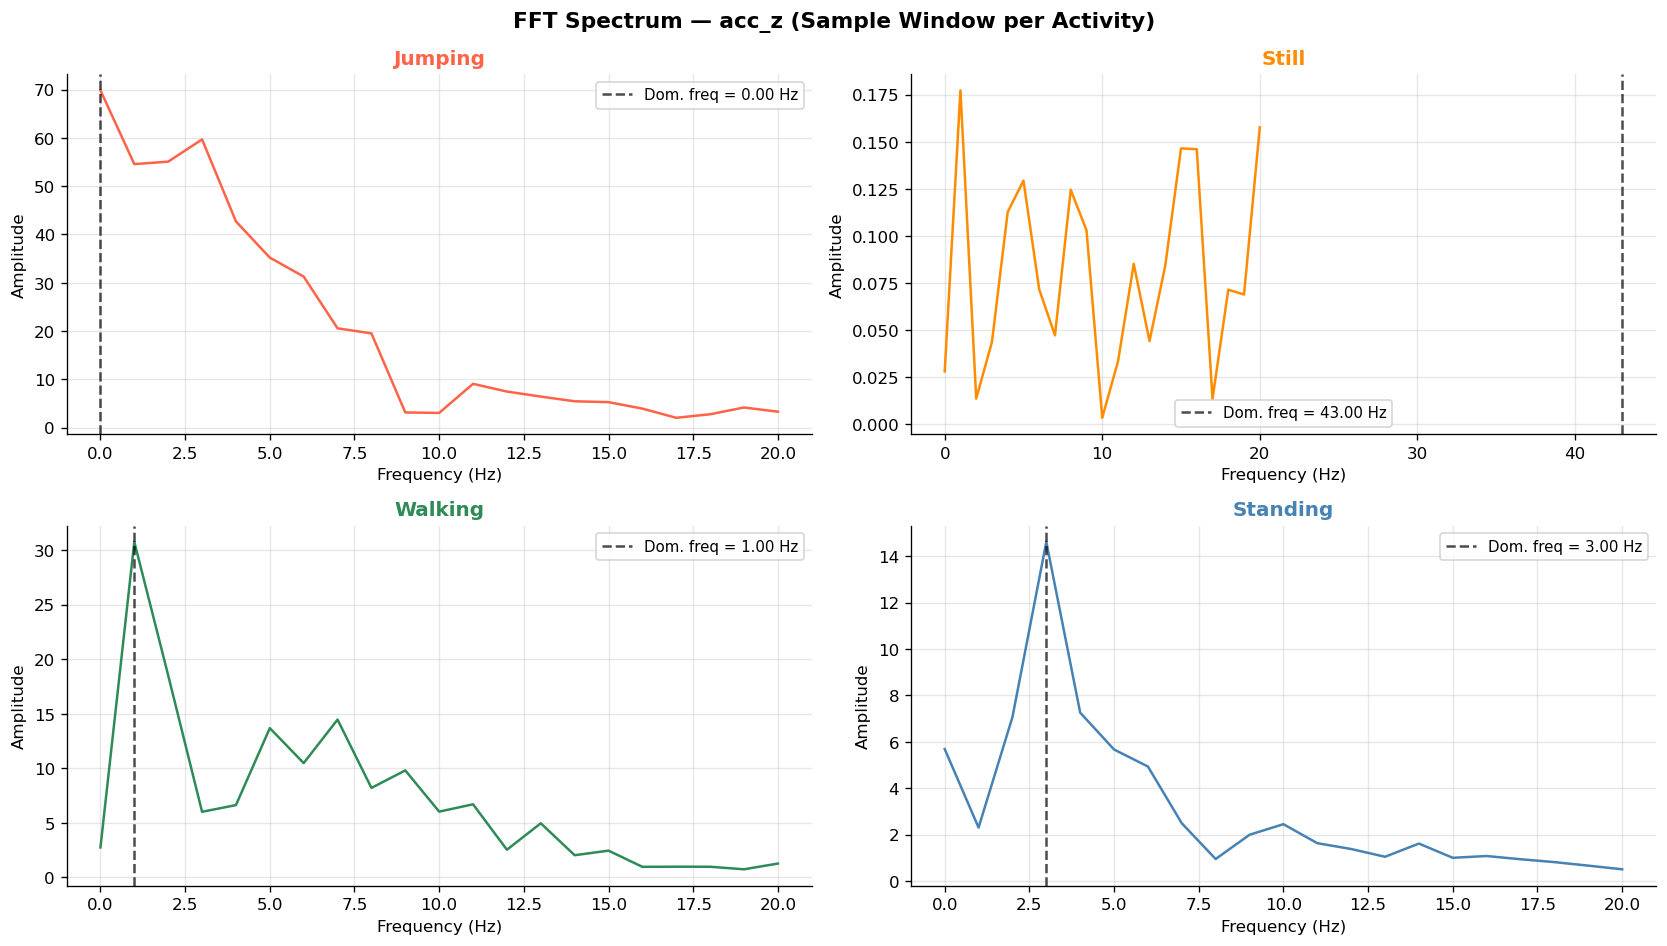

Saved: figures/fft_per_activity.png


In [34]:
# Show FFT spectrum for one sample window of each activity
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('FFT Spectrum — acc_z (Sample Window per Activity)', fontsize=13, fontweight='bold')

for ax, act in zip(axes.flatten(), ACTIVITIES):
    # Take first full window of this activity
    rec_df  = raw_data[act].groupby('recording_id').get_group(
        raw_data[act]['recording_id'].unique()[0]
    ).reset_index(drop=True)
    signal  = rec_df['acc_z'].values[:WINDOW_SIZE]
    N       = len(signal)
    freqs   = fftfreq(N, d=1.0 / SAMPLE_RATE)
    mag     = np.abs(fft(signal))[:N // 2]
    pos_f   = freqs[:N // 2]
    mask_f  = pos_f <= 20   # plot up to 20 Hz

    dom_freq = pos_f[np.argmax(mag)]

    ax.plot(pos_f[mask_f], mag[mask_f], color=COLORS[act], linewidth=1.5)
    ax.axvline(dom_freq, color='black', linestyle='--', alpha=0.7,
               label=f'Dom. freq = {dom_freq:.2f} Hz')
    ax.set_title(act.capitalize(), fontweight='bold', color=COLORS[act])
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fft_per_activity.png'), bbox_inches='tight')
plt.show()
print('Saved: figures/fft_per_activity.png')

## Cell 9 — Z-Score Normalization

**Why Z-score (StandardScaler)?**  
Different features operate on very different scales — spectral energy can reach thousands
while mean acceleration is ~±1g. Z-score normalization rescales every feature to mean=0
and std=1, preventing large-magnitude features from dominating the HMM's Gaussian
emission model during Baum-Welch training.

In [35]:
X_raw = features_df[feature_cols].values
y     = features_df['activity'].values

scaler      = StandardScaler()
X_scaled    = scaler.fit_transform(X_raw)

le          = LabelEncoder()
y_enc       = le.fit_transform(y)
class_names = le.classes_

print('Z-score normalization applied.')
print(f'Mean after scaling : {X_scaled.mean():.6f}  (should be ~0)')
print(f'Std  after scaling : {X_scaled.std():.6f}   (should be ~1)')
print('\nLabel encoding:')
for cls, enc in zip(class_names, le.transform(class_names)):
    print(f'  {cls:>10} -> {enc}')

# Save scaler + encoder so partner can reuse on test data
os.makedirs(MODEL_DIR, exist_ok=True)
with open(os.path.join(MODEL_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(MODEL_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)
print('\nScaler and label encoder saved to models/')

Z-score normalization applied.
Mean after scaling : -0.000000  (should be ~0)
Std  after scaling : 1.000000   (should be ~1)

Label encoding:
     jumping -> 0
    standing -> 1
       still -> 2
     walking -> 3

Scaler and label encoder saved to models/


## Cell 10 — Save Feature Matrix for Partner (Person 2)

In [36]:
# Build final DataFrame with scaled features + labels
features_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
features_scaled_df['activity']     = features_df['activity'].values
features_scaled_df['recording_id'] = features_df['recording_id'].values
features_scaled_df['label_enc']    = y_enc

# Save to CSV — Person 2 loads this for Baum-Welch training
out_path = os.path.join(OUT_DIR, 'features_normalized.csv')
features_scaled_df.to_csv(out_path, index=False)

print(f'Saved: {out_path}')
print(f'Shape: {features_scaled_df.shape}')
print(f'\nPerson 2 should load outputs/features_normalized.csv for HMM training.')

Saved: ../data/processed/features_normalized.csv
Shape: (895, 40)

Person 2 should load outputs/features_normalized.csv for HMM training.


## Cell 11 — Viterbi Decoding

**How Viterbi works here:**  
After Person 2 trains one GaussianHMM per activity using Baum-Welch,
we score each test window against every model using `model.score()` (log-likelihood).
The activity whose model gives the highest log-likelihood is the Viterbi prediction.
This is equivalent to maximum likelihood decoding over the HMM state space.

> **Note:** Run this cell only after Person 2 has trained and saved `models/hmm_models.pkl`

In [37]:
# Load trained HMM models from Person 2
models_path = os.path.join(MODEL_DIR, 'hmm_models.pkl')

if not os.path.exists(models_path):
    print('hmm_models.pkl not found yet.')
    print('Wait for Person 2 to complete Baum-Welch training and share models/hmm_models.pkl')
else:
    with open(models_path, 'rb') as f:
        models = pickle.load(f)
    print(f'Loaded HMM models for: {list(models.keys())}')


def predict_viterbi(X_sequence, models, le):
    """
    Predict activity for each window using Viterbi-based log-likelihood scoring.
    For each window, scores it against every activity HMM and picks the best.
    """
    predictions = []
    for i in range(len(X_sequence)):
        window = X_sequence[i:i+1]   # shape (1, n_features)
        scores = {}
        for cls, model in models.items():
            try:
                scores[cls] = model.score(window)
            except Exception:
                scores[cls] = -np.inf
        predictions.append(max(scores, key=scores.get))
    return np.array(predictions)


print('Viterbi prediction function ready!')
print('Call predict_viterbi(X_test, models, le) after splitting test data.')

hmm_models.pkl not found yet.
Wait for Person 2 to complete Baum-Welch training and share models/hmm_models.pkl
Viterbi prediction function ready!
Call predict_viterbi(X_test, models, le) after splitting test data.


## Cell 12 — Transition Matrix Heatmap Visualization

> Run after `models/hmm_models.pkl` is available from Person 2.

In [38]:
models_path = os.path.join(MODEL_DIR, 'hmm_models.pkl')

if not os.path.exists(models_path):
    print('Waiting for hmm_models.pkl from Person 2...')
else:
    with open(models_path, 'rb') as f:
        models = pickle.load(f)

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle('Transition Probability Matrices (A) — per Activity HMM',
                 fontsize=13, fontweight='bold')

    for ax, cls in zip(axes, class_names):
        trans = models[cls].transmat_
        n     = trans.shape[0]
        sns.heatmap(
            trans, annot=True, fmt='.2f', cmap='Blues',
            ax=ax, cbar=False, linewidths=0.5,
            xticklabels=[f'S{i}' for i in range(n)],
            yticklabels=[f'S{i}' for i in range(n)]
        )
        ax.set_title(cls.capitalize(), fontweight='bold', color=COLORS[cls])
        ax.set_xlabel('To State')
        ax.set_ylabel('From State')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'transition_matrices.png'), bbox_inches='tight')
    plt.show()
    print('Saved: figures/transition_matrices.png')

Waiting for hmm_models.pkl from Person 2...


## Cell 13 — Decoded Activity Sequence Plot

> Run after `models/hmm_models.pkl` is available and test data is defined.

In [39]:
models_path = os.path.join(MODEL_DIR, 'hmm_models.pkl')

if not os.path.exists(models_path):
    print('Waiting for hmm_models.pkl from Person 2...')
else:
    with open(models_path, 'rb') as f:
        models = pickle.load(f)

    # ── Load test features ───────────────────────────────────────────────────
    # Person 2 saves test indices or a test CSV — load it here
    # For now we demo on the full feature set (replace with actual test split)
    X_demo        = X_scaled[:60]    # first 60 windows as demo
    y_demo_labels = y[:60]

    y_pred_labels = predict_viterbi(X_demo, models, le)

    # Map labels to integers for plotting
    act_to_int = {act: i for i, act in enumerate(ACTIVITIES)}
    gt_int     = [act_to_int.get(a, -1) for a in y_demo_labels]
    pred_int   = [act_to_int.get(a, -1) for a in y_pred_labels]

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    fig.suptitle('Decoded Activity Sequence vs Ground Truth',
                 fontsize=13, fontweight='bold')

    axes[0].plot(gt_int,   drawstyle='steps-post', color='steelblue', linewidth=1.5)
    axes[0].set_title('Ground Truth', fontweight='bold')
    axes[0].set_yticks(range(len(ACTIVITIES)))
    axes[0].set_yticklabels(ACTIVITIES)
    axes[0].grid(alpha=0.3)

    axes[1].plot(pred_int, drawstyle='steps-post', color='tomato', linewidth=1.5)
    axes[1].set_title('HMM Predictions (Viterbi)', fontweight='bold')
    axes[1].set_yticks(range(len(ACTIVITIES)))
    axes[1].set_yticklabels(ACTIVITIES)
    axes[1].set_xlabel('Window Index')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'decoded_sequence.png'), bbox_inches='tight')
    plt.show()
    print('Saved: figures/decoded_sequence.png')

Waiting for hmm_models.pkl from Person 2...


## Summary — Person 1 Outputs

| Output file | Description |
|---|---|
| `outputs/features_normalized.csv` | Normalized feature matrix — **send to Person 2 for training** |
| `models/scaler.pkl` | StandardScaler — needed to normalize unseen test data |
| `models/label_encoder.pkl` | LabelEncoder — maps activity names to integers |
| `figures/raw_signals.png` | Raw accelerometer + gyroscope plots |
| `figures/fft_per_activity.png` | FFT dominant frequency per activity |
| `figures/transition_matrices.png` | Transition probability heatmaps *(after models ready)* |
| `figures/decoded_sequence.png` | Viterbi decoded sequence plot *(after models ready)* |